In [1]:
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.13.0+cu130
torchvision version: 0.28.0+cu130


In [2]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

try:
  from torchmetrics import Accuracy
except:
  print("[INFO] Couldn't find torchmetrics... installing it.")
  !pip install -q torchmetrics
  from torchmetrics import Accuracy

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
#!/bin/bash
!curl -L -o dog-and-cat-classification-dataset.zip https://www.kaggle.com/api/v1/datasets/download/bhavikjikadara/dog-and-cat-classification-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  775M  100  775M    0     0   104M      0  0:00:07  0:00:07 --:--:-- 89.2M


In [5]:
import os
import zipfile

from pathlib import Path

data_path = Path("data")
image_path = data_path / "dog_cat_classification"

if image_path.exists():
    print(f"{image_path} already exists")
else:
    print(f"Creating {image_path}...")
    image_path.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile("dog-and-cat-classification-dataset.zip", "r") as zip_ref:
        print("Extracting files...")
        zip_ref.extractall(image_path)

    print(f"Extracted files.")


data/dog_cat_classification already exists


In [6]:
dog_dir = image_path / "PetImages" /"Dog"
cat_dir = image_path / "PetImages" / "Cat"

print(f"There are {len(os.listdir(dog_dir))} images of dogs.")
print(f"There are {len(os.listdir(cat_dir))} images of cats.")

There are 12499 images of dogs.
There are 12499 images of cats.


In [7]:
import pandas as pd

df = pd.DataFrame(columns=["image_path", "label"])
for path in dog_dir.glob("*.jpg"):
    df = pd.concat(
        [
            df,
            pd.DataFrame({"image_path": [path], "label": ["dog"]}),
        ],
        ignore_index=True,
    )

for path in cat_dir.glob("*.jpg"):
    df = pd.concat(
        [
            df,
            pd.DataFrame({"image_path": [path], "label": ["cat"]}),
        ],
        ignore_index=True,
    )

df.head(10)

,image_path,label
0,data/dog_cat_classification/PetImages/Dog/7451...,dog
1,data/dog_cat_classification/PetImages/Dog/583.jpg,dog
2,data/dog_cat_classification/PetImages/Dog/1244...,dog
3,data/dog_cat_classification/PetImages/Dog/9764...,dog
4,data/dog_cat_classification/PetImages/Dog/9975...,dog
5,data/dog_cat_classification/PetImages/Dog/2038...,dog
6,data/dog_cat_classification/PetImages/Dog/2465...,dog
7,data/dog_cat_classification/PetImages/Dog/1152...,dog
8,data/dog_cat_classification/PetImages/Dog/1888...,dog
9,data/dog_cat_classification/PetImages/Dog/2338...,dog


<Axes: xlabel='label', ylabel='Count'>

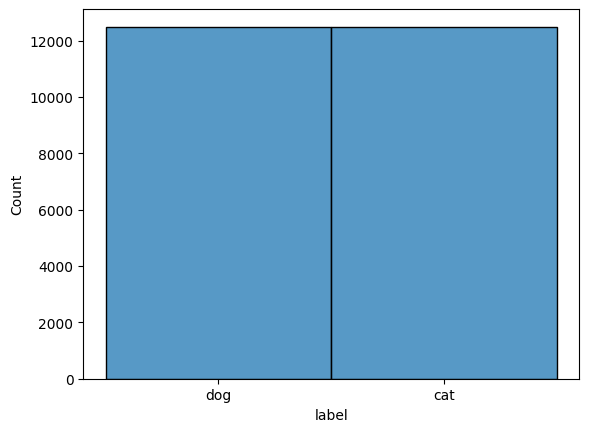

In [8]:
import seaborn as sns

sns.histplot(data=df, x="label")

In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

len(train_df), len(test_df)

(19998, 5000)

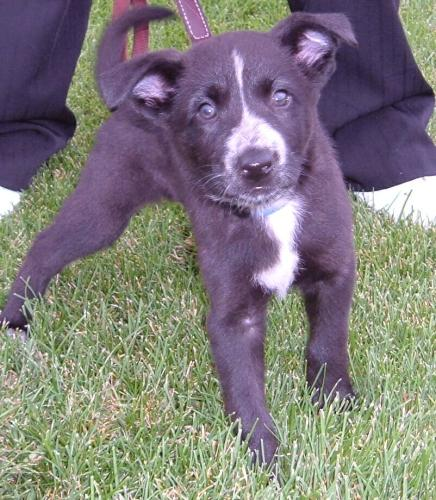

In [10]:
import random
from PIL import Image

random.seed(42)

random_index = random.randint(0, len(train_df) - 1)
img_path = train_df.iloc[random_index]["image_path"]
img = Image.open(img_path)
img

In [11]:
weights = torchvision.models.MobileNet_V3_Small_Weights.DEFAULT
transforms = weights.transforms()

In [12]:
for index, row_data in train_df.iterrows():
    label = row_data["label"]
    img_path = row_data["image_path"]

    train_path = image_path / "train"
    if label == "dog":
        train_path = train_path / "dog"
    else:
        train_path = train_path / "cat"

    if not train_path.exists():
        train_path.mkdir(parents=True, exist_ok=True)

    img = Image.open(img_path)
    # Convert image to RGB mode if it's not already, as JPEG does not support P mode
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img.save(train_path / img_path.name)

/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [13]:
for index, row_data in test_df.iterrows():
    label = row_data["label"]
    img_path = row_data["image_path"]

    test_path = image_path / "test"
    if label == "dog":
        test_path = test_path / "dog"
    else:
        test_path = test_path / "cat"

    if not test_path.exists():
        test_path.mkdir(parents=True, exist_ok=True)

    img = Image.open(img_path)
    # Convert image to RGB mode if it's not already, as JPEG does not support P mode
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img.save(test_path / img_path.name)

In [14]:
from torchvision import datasets

train_data = datasets.ImageFolder(image_path / "train", transform=transforms)
test_data = datasets.ImageFolder(image_path / "test", transform=transforms)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 19998
    Root location: data/dog_cat_classification/train
    StandardTransform
Transform: ImageClassification(
               crop_size=[224]
               resize_size=[256]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BILINEAR
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 5000
    Root location: data/dog_cat_classification/test
    StandardTransform
Transform: ImageClassification(
               crop_size=[224]
               resize_size=[256]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BILINEAR
           )


In [15]:
train_data.classes

['cat', 'dog']

In [16]:
train_dataloader = torch.utils.data.DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=os.cpu_count(),
)

test_dataloader = torch.utils.data.DataLoader(
    test_data,
    batch_size=32,
    shuffle=False,
    num_workers=os.cpu_count(),
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7e031d93d2b0>,
 <torch.utils.data.dataloader.DataLoader at 0x7e031d82f4d0>)

In [17]:
model = torchvision.models.mobilenet_v3_small(weights=weights)

summary(model, input_size=(1, 3, 224, 224), col_names=["input_size", "output_size", "num_params", "trainable"], verbose=0)

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Trainable
MobileNetV3                                        [1, 3, 224, 224]          [1, 1000]                 --                        True
├─Sequential: 1-1                                  [1, 3, 224, 224]          [1, 576, 7, 7]            --                        True
│    └─Conv2dNormActivation: 2-1                   [1, 3, 224, 224]          [1, 16, 112, 112]         --                        True
│    │    └─Conv2d: 3-1                            [1, 3, 224, 224]          [1, 16, 112, 112]         432                       True
│    │    └─BatchNorm2d: 3-2                       [1, 16, 112, 112]         [1, 16, 112, 112]         32                        True
│    │    └─Hardswish: 3-3                         [1, 16, 112, 112]         [1, 16, 112, 112]         --                        --
│    └─InvertedResidual: 2-2                       [1, 16, 

In [18]:
def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
):
    model.train()
    train_loss, train_acc = 0,0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        y_logits = model(X)
        y_pred = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)

        loss = loss_fn(y_logits, y)
        train_loss += loss
        train_acc += (y_pred == y).sum().item() / len(y_pred)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss.item(), train_acc

In [19]:
def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    device: torch.device,
):
    model.eval()
    with torch.inference_mode():
        test_loss, test_acc = 0,0
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            test_logits = model(X)
            test_pred = torch.argmax(torch.softmax(test_logits, dim=1), dim=1)

            loss = loss_fn(test_logits, y)
            test_loss += loss
            test_acc += (test_pred == y).sum().item() / len(test_pred)

        test_loss /= len(dataloader)
        test_acc /= len(dataloader)
    return test_loss.item(), test_acc

In [20]:
from tqdm.auto import tqdm

def train_loop(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module,
    epochs: int,
    device: torch.device,
):
    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    for epoch in tqdm(range(epochs)):
      train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
      test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)
      print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
      )

      results["train_loss"].append(train_loss)
      results["train_acc"].append(train_acc)
      results["test_loss"].append(test_loss)
      results["test_acc"].append(test_acc)

    return results

In [21]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model_results = train_loop(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=10,
    device=device,
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.1752 | train_acc: 0.9421 | test_loss: 0.1315 | test_acc: 0.9480
Epoch: 2 | train_loss: 0.0723 | train_acc: 0.9714 | test_loss: 0.1267 | test_acc: 0.9443
Epoch: 3 | train_loss: 0.0556 | train_acc: 0.9787 | test_loss: 0.1007 | test_acc: 0.9624
Epoch: 4 | train_loss: 0.0485 | train_acc: 0.9821 | test_loss: 0.1714 | test_acc: 0.9455
Epoch: 5 | train_loss: 0.0395 | train_acc: 0.9845 | test_loss: 0.0978 | test_acc: 0.9654
Epoch: 6 | train_loss: 0.0362 | train_acc: 0.9865 | test_loss: 0.1172 | test_acc: 0.9620
Epoch: 7 | train_loss: 0.0330 | train_acc: 0.9879 | test_loss: 0.1050 | test_acc: 0.9646
Epoch: 8 | train_loss: 0.0262 | train_acc: 0.9909 | test_loss: 0.1154 | test_acc: 0.9648
Epoch: 9 | train_loss: 0.0340 | train_acc: 0.9880 | test_loss: 0.1052 | test_acc: 0.9648
Epoch: 10 | train_loss: 0.0253 | train_acc: 0.9906 | test_loss: 0.1098 | test_acc: 0.9628


In [22]:
import requests

custom_image_path = data_path / "cat.jpg"

if custom_image_path.exists():
  print(f"{custom_image_path} already exists")
else:
  print(f"Downloading {custom_image_path}...")

  request = requests.get("https://protectapet.com/cdn/shop/articles/5-reasons-to-love-black-cats.jpg?v=1608638024&width=1920")
  with open(custom_image_path, "wb") as f:
    f.write(request.content)

data/cat.jpg already exists


(np.float64(-0.5), np.float64(1199.5), np.float64(1199.5), np.float64(-0.5))

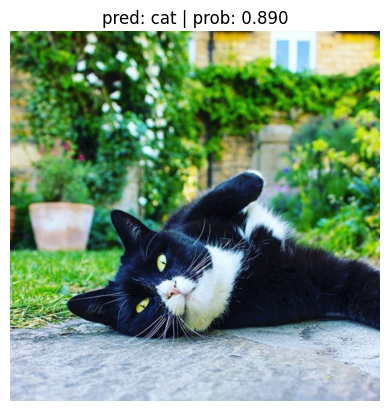

In [23]:
image = Image.open(custom_image_path)
input_image = transforms(image).unsqueeze_(0).to(device)

model.eval()
with torch.inference_mode():
  pred_logits = model(input_image)
  pred_prob = torch.softmax(pred_logits, dim=1)
  pred_label = torch.argmax(pred_prob, dim=1)

plt.figure()
plt.imshow(Image.open(custom_image_path))
plt.title(f"pred: {train_data.classes[pred_label]} | prob: {pred_prob.max():.3f}")
plt.axis(False)